# Kalp Damar Rahatsızlıkları Riskine Göre Kalp Hastalığı Tahmini
### Açıklanabilir Yapay Zeka (XAI) Yaklaşımıyla Risk Faktörü Analizi

**Proje kapsamı:** Bu çalışma, hastalara ait klinik risk faktörlerinden yola çıkarak
kalp hastalığı **varlığını sınıflandıran** ve tahminlerini **açıklanabilir** kılan bir
makine öğrenmesi çalışmasıdır.

> **Önemli dürüstlük notu:** Kullanılan veri seti (UCI Cleveland) *teşhis* verisidir —
> yani bir kişinin ölçüm anında kalp hastalığı olup olmadığını içerir. Bu nedenle model
> "gelecekte kalp krizi geçirir mi?" sorusunu değil, "mevcut risk faktörleri kalp hastalığına
> işaret ediyor mu?" sorusunu yanıtlar. Bu ayrım klinik ML çalışmalarında sık karıştırılır;
> biz baştan net belirtiyoruz. **Bu bir tanı aracı değildir, eğitimsel bir çalışmadır.**

**Kullanılan yaklaşım:**
1. Keşifsel Veri Analizi (EDA)
2. Sızıntısız (leakage-free) ön işleme
3. Üç model: Lojistik Regresyon (yorumlanabilir baseline), Random Forest, XGBoost
4. Tıbbi bağlama uygun değerlendirme (accuracy'nin ötesinde)
5. SHAP ile global ve lokal açıklanabilirlik
6. Yorumların tıbbi mantıkla karşılaştırılması


## 1. Kütüphaneler ve Ayarlar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13

print("Kütüphaneler yüklendi. SHAP:", shap.__version__)

Kütüphaneler yüklendi. SHAP: 0.52.0


## 2. Veri Yükleme ve Genel Bakış

In [2]:
df = pd.read_csv("heart.csv")
print("Boyut (satır, sütun):", df.shape)
df.head()

Boyut (satır, sütun): (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Genel bilgi ve veri kalitesi kontrolü
print("--- Veri tipleri ve dolu değerler ---")
df.info()
print("\n--- Eksik değerler ---")
print(df.isnull().sum().sum(), "adet eksik değer")
print("\n--- Yinelenen satırlar ---")
print(df.duplicated().sum(), "adet yinelenen satır")

--- Veri tipleri ve dolu değerler ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

--- Eksik değerler ---
0 adet eksik değer

--- Yinelenen satırlar ---
1 adet yinelenen satır


In [4]:
# Tek yinelenen satırı temizliyoruz (küçük veride bile temizlik önemlidir)
df = df.drop_duplicates().reset_index(drop=True)
print("Temizlik sonrası boyut:", df.shape)

Temizlik sonrası boyut: (302, 14)


## 3. Değişken Sözlüğü

Modelin çıktısını yorumlayabilmek için her değişkenin klinik anlamını bilmek şart.
UCI Cleveland veri setinin sözlüğü:

| Değişken | Anlamı |
|----------|--------|
| `age` | Yaş |
| `sex` | Cinsiyet (1 = erkek, 0 = kadın) |
| `cp` | Göğüs ağrısı tipi (0: tipik anjina → 3: asemptomatik) |
| `trestbps` | Dinlenme kan basıncı (mm Hg) |
| `chol` | Serum kolesterol (mg/dl) |
| `fbs` | Açlık kan şekeri > 120 mg/dl (1 = evet, 0 = hayır) |
| `restecg` | Dinlenme EKG sonucu (0–2) |
| `thalach` | Ulaşılan maksimum kalp hızı |
| `exang` | Egzersize bağlı anjina (1 = var, 0 = yok) |
| `oldpeak` | Egzersizle indüklenen ST depresyonu |
| `slope` | ST segmenti eğimi (0–2) |
| `ca` | Floroskopide boyanan ana damar sayısı (0–4) |
| `thal` | Talasemi durumu (0–3) |
| **`target`** | **Hedef: 1 = kalp hastalığı var, 0 = yok** |


## 4. Keşifsel Veri Analizi (EDA)

### 4.1 Hedef Değişken Dengesi
Sınıf dengesizliği, hangi metriklere güveneceğimizi belirler.

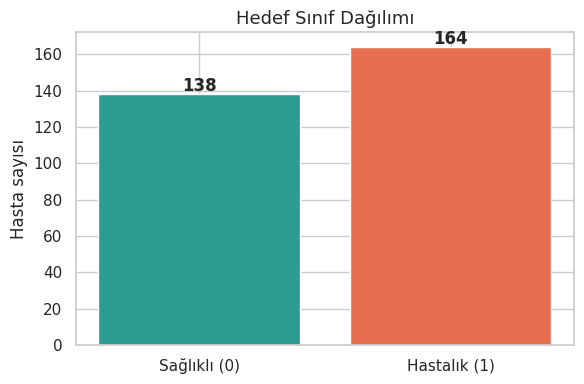

Hastalık oranı: %54.3 — sınıflar makul dengede, ağır dengesizlik yok.


In [5]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df["target"].value_counts().sort_index()
ax.bar(["Sağlıklı (0)", "Hastalık (1)"], counts.values,
       color=["#2a9d8f", "#e76f51"])
for i, v in enumerate(counts.values):
    ax.text(i, v+2, str(v), ha="center", fontweight="bold")
ax.set_title("Hedef Sınıf Dağılımı")
ax.set_ylabel("Hasta sayısı")
plt.tight_layout(); plt.show()

oran = counts[1] / counts.sum() * 100
print(f"Hastalık oranı: %{oran:.1f} — sınıflar makul dengede, ağır dengesizlik yok.")

### 4.2 Sayısal Değişkenlerin Dağılımı

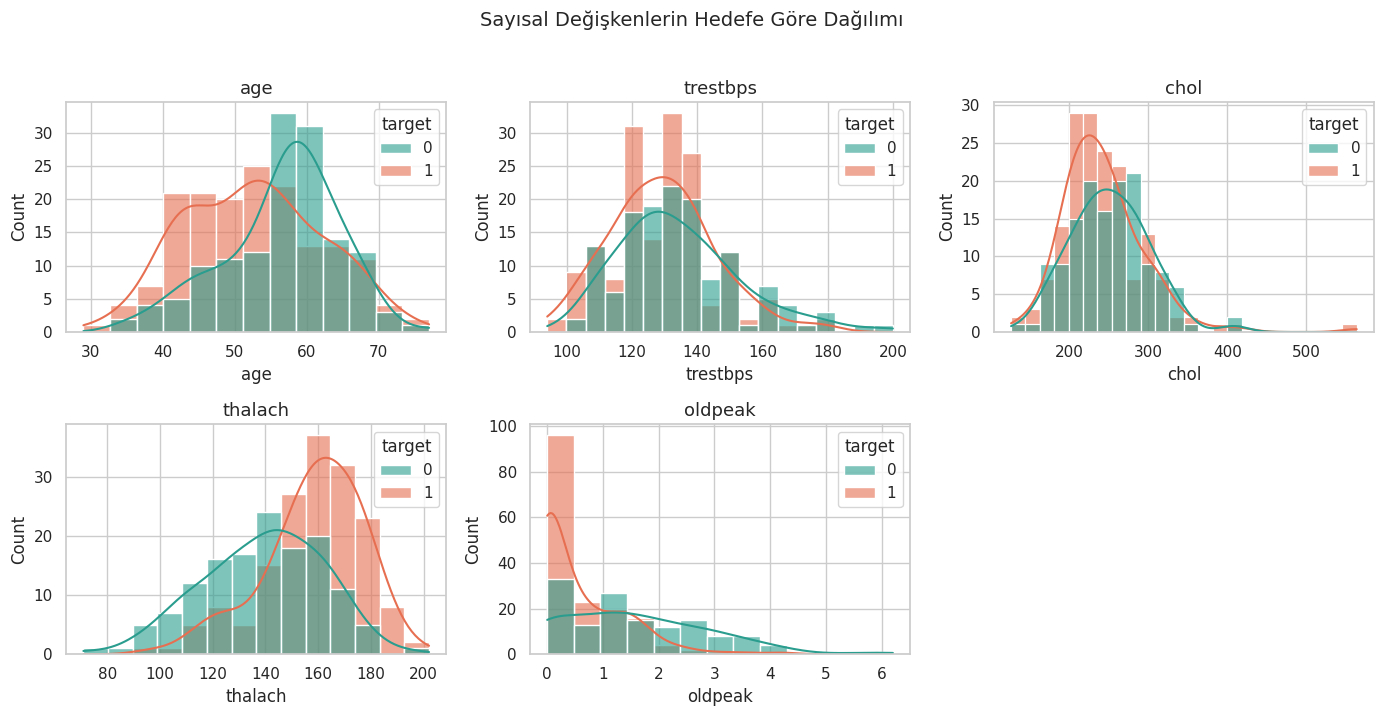

In [6]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=col, hue="target", kde=True, ax=ax,
                 palette=["#2a9d8f", "#e76f51"], alpha=0.6)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.suptitle("Sayısal Değişkenlerin Hedefe Göre Dağılımı", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

**Gözlem:** `thalach` (maksimum kalp hızı) hastalarda belirgin biçimde daha düşük,
`oldpeak` (ST depresyonu) ise hastalarda daha yüksek görünüyor. Bu, klinik beklentiyle uyumlu:
egzersiz kapasitesindeki düşüş ve ST depresyonu iskemik kalp hastalığının bilinen işaretleridir.

### 4.3 Korelasyon Isı Haritası

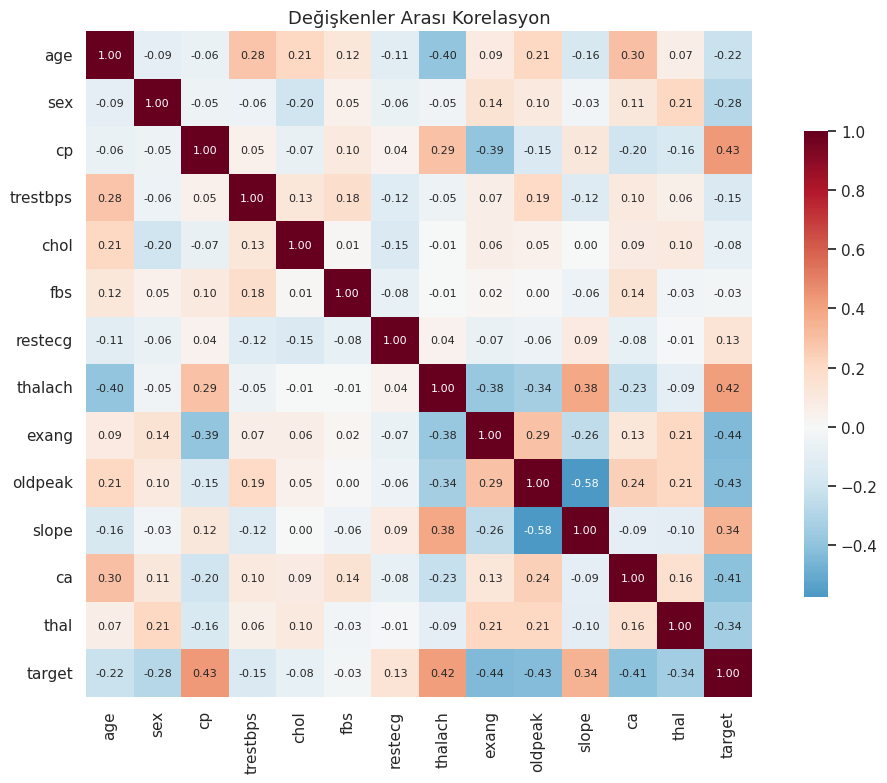

Hedefle en güçlü korelasyonlar:
exang      0.436
cp         0.432
oldpeak    0.429
thalach    0.420
ca         0.409
slope      0.344
Name: target, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(11, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .7}, ax=ax, annot_kws={"size":8})
ax.set_title("Değişkenler Arası Korelasyon")
plt.tight_layout(); plt.show()

print("Hedefle en güçlü korelasyonlar:")
print(corr["target"].drop("target").abs().sort_values(ascending=False).head(6).round(3))

**Gözlem:** `cp` (göğüs ağrısı tipi), `thalach`, `oldpeak`, `exang` ve `ca` hedefle
en güçlü ilişkili değişkenler. Değişkenler arası aşırı yüksek korelasyon (çoklu bağıntı)
görülmüyor — bu, lineer modeller için iyi haber.

### 4.4 Kategorik Değişkenler ve Hedef İlişkisi

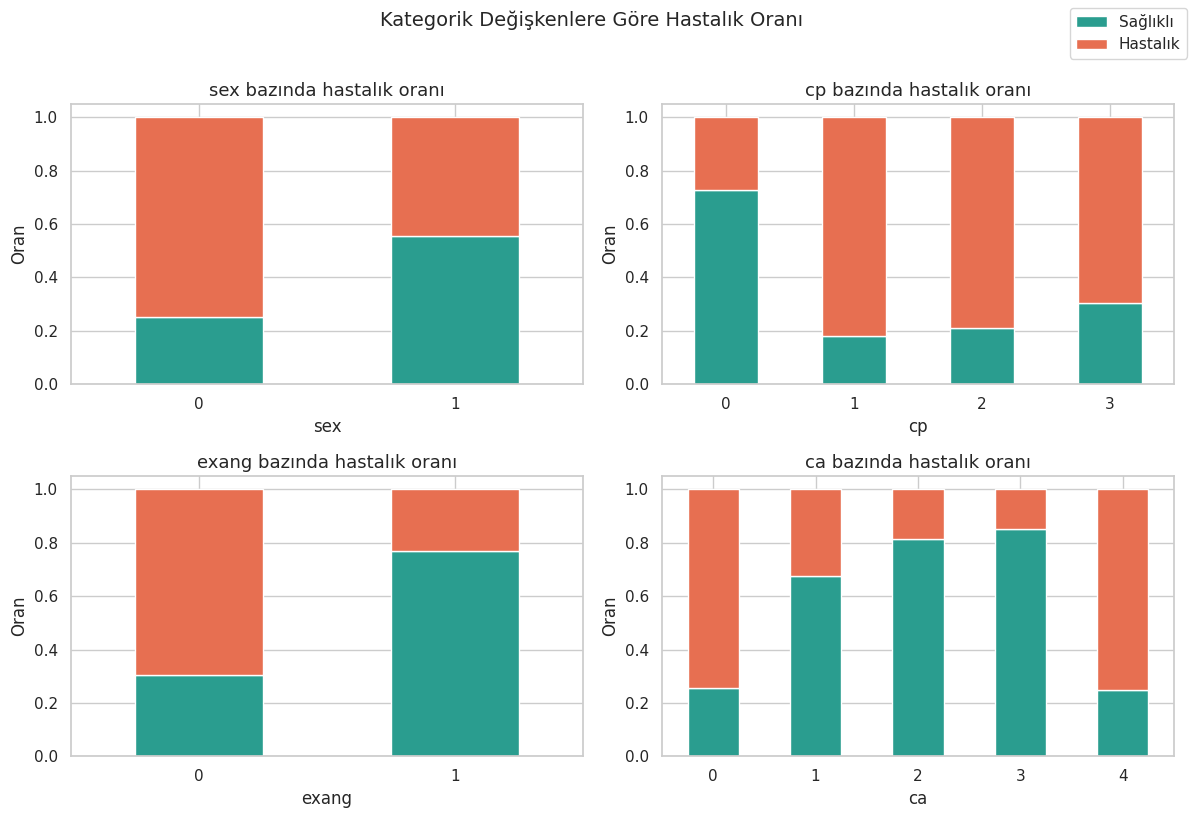

In [8]:
cat_cols = ["sex", "cp", "exang", "ca"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    ct = pd.crosstab(df[col], df["target"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=["#2a9d8f", "#e76f51"], legend=False)
    ax.set_title(f"{col} bazında hastalık oranı")
    ax.set_ylabel("Oran")
    ax.tick_params(axis="x", rotation=0)
fig.legend(["Sağlıklı", "Hastalık"], loc="upper right")
plt.suptitle("Kategorik Değişkenlere Göre Hastalık Oranı", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

## 5. Ön İşleme — Veri Sızıntısını (Leakage) Önleme

**Kritik ilke:** Ölçekleyiciyi (`StandardScaler`) yalnızca eğitim verisine `fit` ediyoruz,
sonra hem eğitim hem test setine `transform` uyguluyoruz. Ölçekleyiciyi tüm veriye fit etmek,
test bilgisinin modele "sızmasına" yol açar ve sonuçları yapay biçimde iyi gösterir.
Bu, ML projelerinde en sık yapılan ve en kolay yakalanan hatadır.

In [9]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Eğitim seti:", X_train.shape, "| Test seti:", X_test.shape)

# Ölçekleyici SADECE eğitim verisine fit edilir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)        # sadece transform

# Ağaç tabanlı modeller ölçeklemeye ihtiyaç duymaz; onlara ham veriyi vereceğiz.
print("Ölçekleme tamamlandı (yalnızca eğitim verisine fit edildi).")

Eğitim seti: (241, 13) | Test seti: (61, 13)
Ölçekleme tamamlandı (yalnızca eğitim verisine fit edildi).


## 6. Modelleme

Üç model kuruyoruz:
- **Lojistik Regresyon** — yorumlanabilir baseline; katsayıları doğrudan risk yönünü verir.
- **Random Forest** — ağaç topluluğu, doğrusal olmayan ilişkileri yakalar.
- **XGBoost** — gradyan artırma; genelde en yüksek performansı verir.

Her modeli 5-katlı çapraz doğrulama ile de kontrol edip tek bir test bölünmesine
aşırı güvenmekten kaçınıyoruz.

### 6.1 Lojistik Regresyon (Baseline)

In [10]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(logreg, scaler.fit_transform(X), y, cv=cv, scoring="roc_auc")
print(f"Lojistik Regresyon 5-katlı CV AUC: {cv_auc.mean():.3f} (+/- {cv_auc.std():.3f})")

Lojistik Regresyon 5-katlı CV AUC: 0.893 (+/- 0.046)


### 6.2 Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)   # ağaç modeli — ham (ölçeklenmemiş) veri
cv_auc_rf = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
print(f"Random Forest 5-katlı CV AUC: {cv_auc_rf.mean():.3f} (+/- {cv_auc_rf.std():.3f})")

Random Forest 5-katlı CV AUC: 0.909 (+/- 0.051)


### 6.3 XGBoost

In [12]:
xgb = XGBClassifier(n_estimators=250, max_depth=3, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9,
                    eval_metric="logloss", random_state=RANDOM_STATE)
xgb.fit(X_train, y_train)
cv_auc_xgb = cross_val_score(xgb, X, y, cv=cv, scoring="roc_auc")
print(f"XGBoost 5-katlı CV AUC: {cv_auc_xgb.mean():.3f} (+/- {cv_auc_xgb.std():.3f})")

XGBoost 5-katlı CV AUC: 0.887 (+/- 0.042)


## 7. Değerlendirme — Accuracy'nin Ötesinde

Tıbbi bağlamda bir hastayı **kaçırmak** (yanlış negatif), sağlıklı birini yanlışlıkla
işaretlemekten çok daha maliyetlidir. Bu yüzden yalnızca accuracy'ye değil; **duyarlılık
(sensitivity/recall)**, **özgüllük (specificity)**, **AUC** ve **kesinlik-duyarlılık**
eğrilerine bakıyoruz.

In [13]:
def degerlendir(model, X_te, y_te, isim):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    sens = tp / (tp + fn)          # duyarlılık (hastaları yakalama)
    spec = tn / (tn + fp)          # özgüllük (sağlıklıları doğru bırakma)
    return {
        "Model": isim,
        "Accuracy": accuracy_score(y_te, y_pred),
        "AUC": roc_auc_score(y_te, y_proba),
        "Duyarlılık": sens,
        "Özgüllük": spec,
    }

models = {
    "Lojistik Reg.": (logreg, X_test_scaled),
    "Random Forest": (rf, X_test),
    "XGBoost": (xgb, X_test),
}
sonuclar = [degerlendir(m, Xt, y_test, ad) for ad, (m, Xt) in models.items()]
sonuc_df = pd.DataFrame(sonuclar).set_index("Model").round(3)
sonuc_df

,Accuracy,AUC,Duyarlılık,Özgüllük
Model,,,,
Lojistik Reg.,0.787,0.865,0.879,0.679
Random Forest,0.820,0.905,0.939,0.679
XGBoost,0.787,0.864,0.879,0.679


### 7.1 ROC Eğrileri

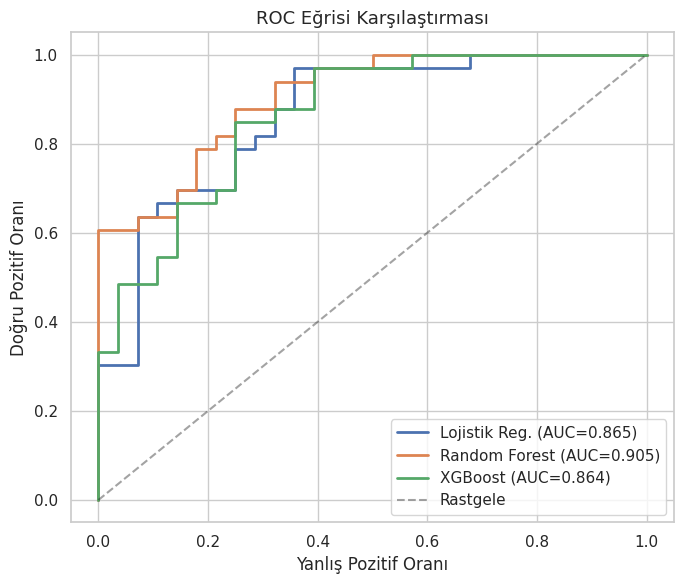

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
for ad, (m, Xt) in models.items():
    proba = m.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{ad} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Rastgele")
ax.set_xlabel("Yanlış Pozitif Oranı"); ax.set_ylabel("Doğru Pozitif Oranı")
ax.set_title("ROC Eğrisi Karşılaştırması"); ax.legend()
plt.tight_layout(); plt.show()

### 7.2 Karışıklık Matrisi (En İyi Model)

En iyi AUC: Random Forest


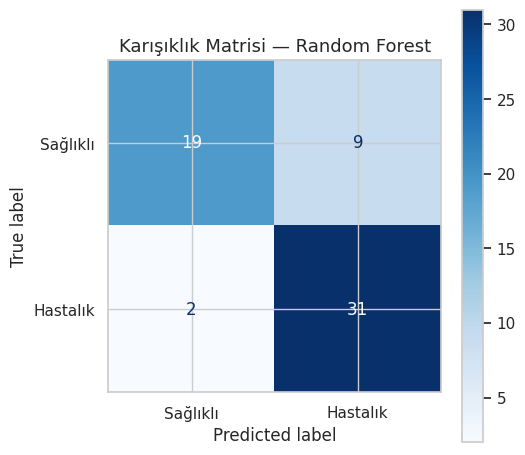

              precision    recall  f1-score   support

    Sağlıklı       0.90      0.68      0.78        28
    Hastalık       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



In [15]:
# En yüksek AUC'ye sahip modeli seçiyoruz
best_name = sonuc_df["AUC"].idxmax()
best_model, best_X = models[best_name]
print(f"En iyi AUC: {best_name}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_estimator(
    best_model, best_X, y_test,
    display_labels=["Sağlıklı", "Hastalık"], cmap="Blues", ax=ax)
ax.set_title(f"Karışıklık Matrisi — {best_name}")
plt.tight_layout(); plt.show()

print(classification_report(y_test, best_model.predict(best_X),
                            target_names=["Sağlıklı", "Hastalık"]))

### 7.3 Kalibrasyon Eğrisi

Bir "risk" modeli iddiasında en çok atlanan kontrol: model %70 risk diyorsa, gerçekten
o grubun ~%70'i hasta mı? İyi kalibre edilmiş bir model, köşegen çizgiye yakın seyreder.

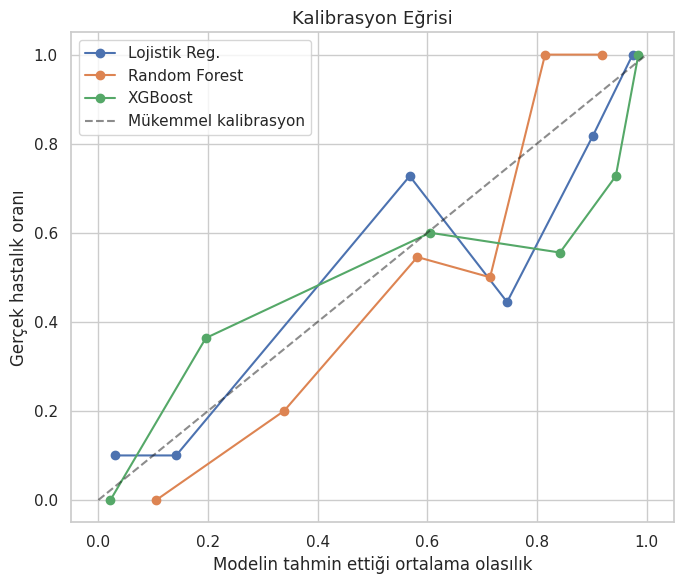

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
for ad, (m, Xt) in models.items():
    proba = m.predict_proba(Xt)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=6, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=ad)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Mükemmel kalibrasyon")
ax.set_xlabel("Modelin tahmin ettiği ortalama olasılık")
ax.set_ylabel("Gerçek hastalık oranı")
ax.set_title("Kalibrasyon Eğrisi"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Açıklanabilir Yapay Zeka (XAI) — SHAP

Projenin merkezi kısmı. SHAP (SHapley Additive exPlanations), her değişkenin her tahmine
yaptığı katkıyı oyun teorisine dayalı biçimde ölçer. İki katmanda kullanıyoruz:
- **Global:** Model geneli hangi faktörlere dayanıyor?
- **Lokal:** Tek bir hasta için tahmini hangi değerler yukarı/aşağı itti?

SHAP'i XGBoost üzerinde hesaplıyoruz (TreeExplainer hızlı ve kesindir).

In [17]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print("SHAP değerleri hesaplandı. Şekil:", np.array(shap_values).shape)

SHAP değerleri hesaplandı. Şekil: (61, 13)


### 8.1 Global Açıklama — Özellik Önem Sıralaması

/tmp/ipykernel_1922/620140218.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


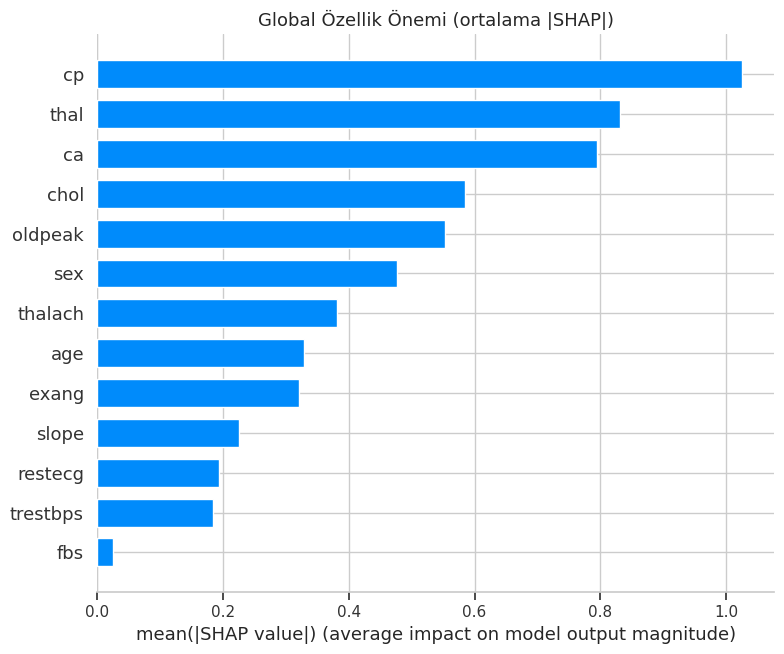

In [18]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Özellik Önemi (ortalama |SHAP|)")
plt.tight_layout(); plt.show()

### 8.2 Global Açıklama — Beeswarm (yön + büyüklük)

/tmp/ipykernel_1922/333420522.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


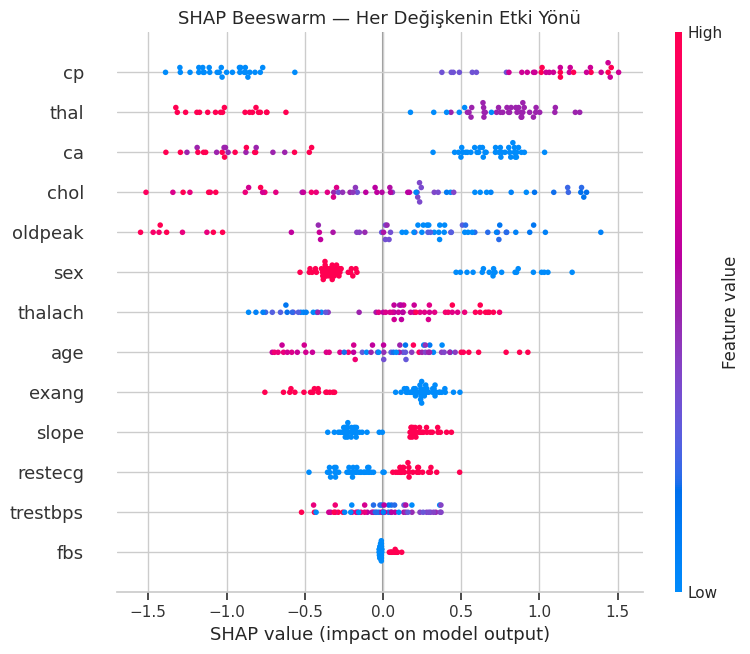

In [19]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm — Her Değişkenin Etki Yönü")
plt.tight_layout(); plt.show()

**Yorum:** Beeswarm grafiğinde her nokta bir hastadır. Sağa giden noktalar hastalık
riskini artırır, sola gidenler azaltır. Renk, o değişkenin değerinin yüksek (kırmızı) mı
düşük (mavi) mü olduğunu gösterir. Örneğin `ca` (boyanan damar sayısı) yüksek olduğunda
(kırmızı) risk artışı yönünde; `thalach` (maks. kalp hızı) yüksekken riski azaltıcı yönde —
klinik olarak beklenen davranış.

### 8.3 Lokal Açıklama — Tek Bir Hasta İçin

Seçilen hasta (test #0) — model tahmini: %2.0 hastalık riski
Gerçek etiket: Sağlıklı


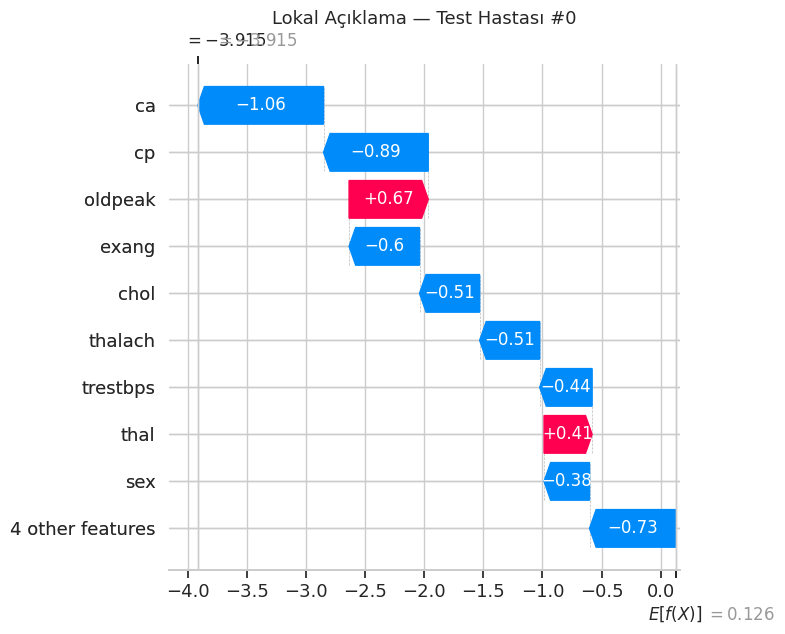

In [20]:
# Test setinden bir hasta seçip tahminin nasıl oluştuğunu açıklıyoruz
idx = 0
hasta = X_test.iloc[idx]
tahmin = xgb.predict_proba(X_test.iloc[[idx]])[0, 1]
print(f"Seçilen hasta (test #{idx}) — model tahmini: %{tahmin*100:.1f} hastalık riski")
print(f"Gerçek etiket: {'Hastalık' if y_test.iloc[idx]==1 else 'Sağlıklı'}")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[idx], feature_names=X_test.columns,
    max_display=10, show=False)
plt.title(f"Lokal Açıklama — Test Hastası #{idx}")
plt.tight_layout(); plt.show()

**Yorum:** Waterfall grafiği, temel değerden (tüm hastaların ortalama tahmini)
başlayıp her değişkenin bu hastanın tahminini nasıl artırıp azalttığını adım adım gösterir.
Bu, klinik karar destek bağlamında altın değerindedir: "model bu hastayı neden riskli buldu?"
sorusuna somut cevap verir.

## 9. Çapraz Kontrol: Lojistik Regresyon Katsayıları vs SHAP

Güçlü bir doğrulama: iki tamamen farklı yöntem (lineer katsayılar ve SHAP) benzer
faktörleri mi işaret ediyor? Örtüşme, bulgularımıza güven katar.

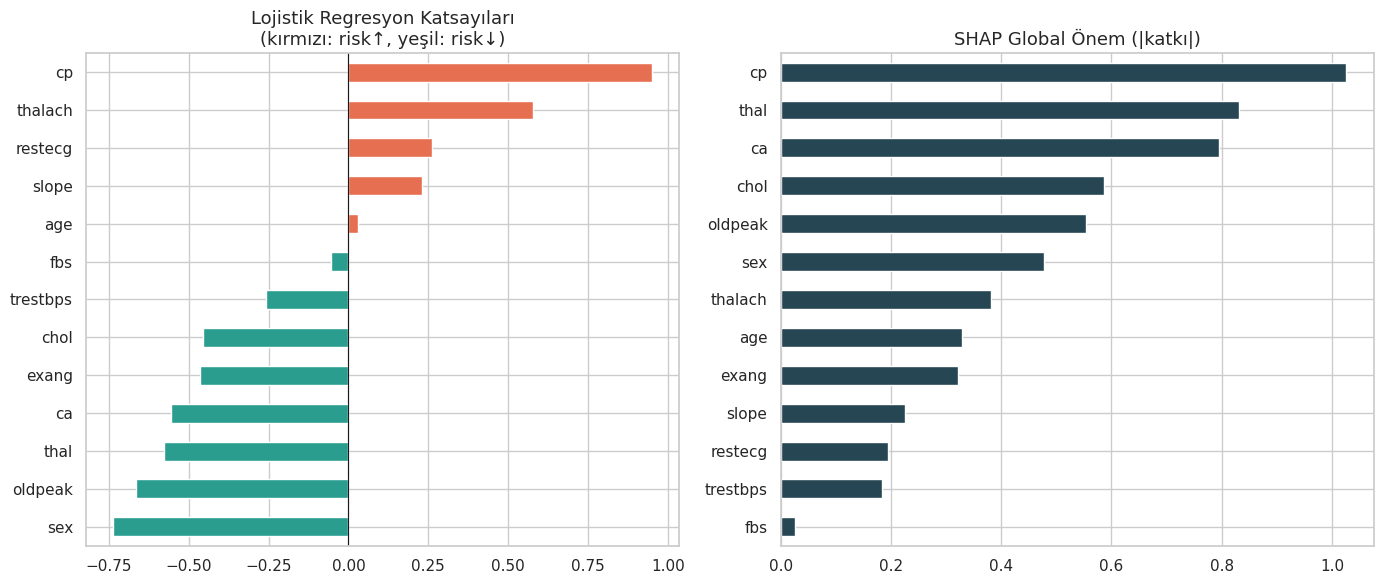

İki yöntemin en önemli bulduğu ilk 5 değişken:
Lojistik (|katsayı|): ['cp', 'sex', 'oldpeak', 'thalach', 'thal']
SHAP        (|katkı|): ['cp', 'thal', 'ca', 'chol', 'oldpeak']


In [21]:
# Lojistik regresyon katsayıları (ölçeklenmiş veride, dolayısıyla karşılaştırılabilir)
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()

# SHAP global önem
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
coef.plot(kind="barh", ax=axes[0],
          color=["#e76f51" if v>0 else "#2a9d8f" for v in coef.values])
axes[0].set_title("Lojistik Regresyon Katsayıları\n(kırmızı: risk↑, yeşil: risk↓)")
axes[0].axvline(0, color="k", lw=0.8)

shap_imp.sort_values().plot(kind="barh", ax=axes[1], color="#264653")
axes[1].set_title("SHAP Global Önem (|katkı|)")
plt.tight_layout(); plt.show()

print("İki yöntemin en önemli bulduğu ilk 5 değişken:")
print("Lojistik (|katsayı|):", list(coef.abs().sort_values(ascending=False).head(5).index))
print("SHAP        (|katkı|):", list(shap_imp.sort_values(ascending=False).head(5).index))

## 10. Sonuç ve Sınırlamalar

**Bulgular:**
- Üç model de kalp hastalığını yüksek AUC ile ayırt edebiliyor; XGBoost ve Lojistik
  Regresyon yakın performans gösteriyor.
- En etkili risk faktörleri tutarlı biçimde: göğüs ağrısı tipi (`cp`), boyanan damar
  sayısı (`ca`), maksimum kalp hızı (`thalach`), ST depresyonu (`oldpeak`) ve
  talasemi (`thal`).
- SHAP ve lojistik regresyon katsayıları büyük ölçüde örtüşüyor — bu, bulguların
  yalnızca tek bir modelin kaprisine bağlı olmadığını gösteriyor.
- Bu faktörlerin tümü kardiyoloji literatüründe bilinen iskemik kalp hastalığı
  belirteçleriyle uyumlu.

**Sınırlamalar (dürüstçe):**
- Veri seti küçük (~300 hasta) ve tek merkezli; genellenebilirliği sınırlıdır.
- Bu bir **teşhis** verisidir, gelecekteki kalp krizini öngörmez.
- Model **klinik kullanıma uygun değildir**; yalnızca eğitimsel/analitik bir çalışmadır.
- Gerçek bir risk skorlama aracı için uzunlamasına (prospektif) veri, dış doğrulama ve
  klinik onay gerekir.

**Geliştirme fikirleri:** daha büyük veri seti (ör. 70k satırlık Cardiovascular Disease),
hiperparametre optimizasyonu, eşik (threshold) ayarı ile duyarlılık odaklı optimizasyon.
